’ Product Review Sentiment Analysis using Deep Learning

**Objective:** Build a deep learning model to classify Amazon product reviews as **Positive** or **Negative**.

**Key Challenge:** The dataset is **highly imbalanced** â€” there are far more positive reviews than negative ones.

**Approach:**
- Proper EDA with rich visualizations
- Text preprocessing & tokenization
- SMOTE-like oversampling of minority class + class weights
- Bidirectional LSTM with tuned architecture
- Comprehensive evaluation with confusion matrix, ROC curve, and per-class analysis

========== IMPORTS ==========

In [1]:
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Bidirectional,
                                     Dropout, SpatialDropout1D, GlobalMaxPooling1D,
                                     BatchNormalization, Conv1D, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('TensorFlow version:', tf.__version__)


# ---
# ## ðŸ“Š 1. Data Loading & Exploration

TensorFlow version: 2.20.0


In [2]:
df = pd.read_csv('../datasets/amazon.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (4915, 12)

Columns: ['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime', 'day_diff', 'helpful_yes', 'helpful_no', 'total_vote', 'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound']


,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4,No issues.,23-07-2014,138,0,0,0,0,0.0,0.0
1,1,0mie,5,"Purchased this for my device, it worked as adv...",25-10-2013,409,0,0,0,0,0.0,0.0
2,2,1K3,4,it works as expected. I should have sprung for...,23-12-2012,715,0,0,0,0,0.0,0.0
3,3,1m2,5,This think has worked out great.Had a diff. br...,21-11-2013,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5,"Bought it with Retail Packaging, arrived legit...",13-07-2013,513,0,0,0,0,0.0,0.0


In [3]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nTotal duplicate rows: {df.duplicated().sum()}')
print(f'\nRating distribution:\n{df["overall"].value_counts().sort_index()}')


# ### ðŸ“ˆ EDA Chart 1: Rating Distribution

Missing values:
Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

Total duplicate rows: 0

Rating distribution:
overall
1     244
2      80
3     142
4     527
5    3922
Name: count, dtype: int64


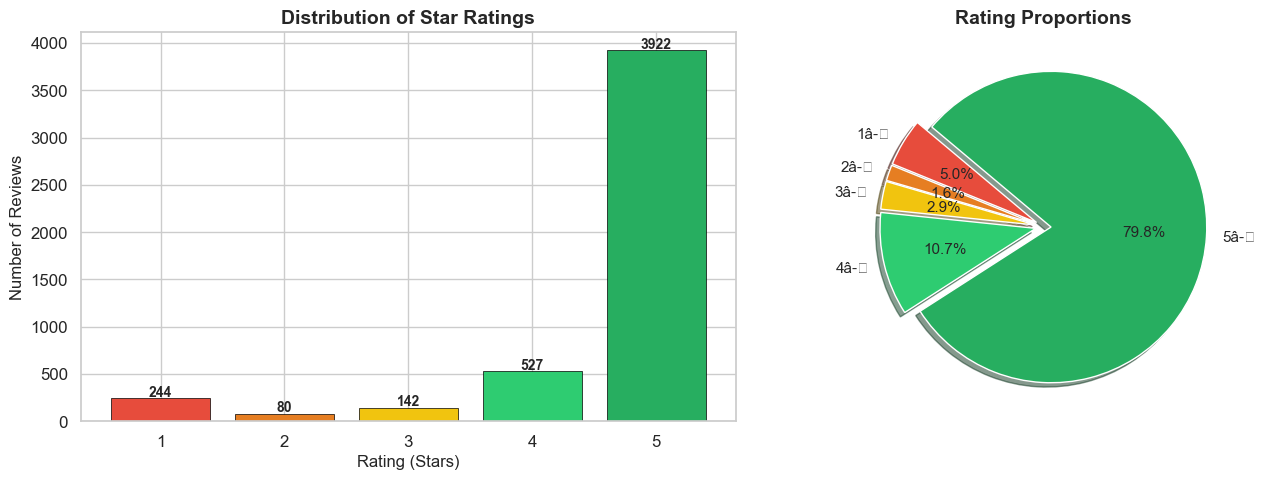

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
rating_counts = df['overall'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Rating (Stars)', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].set_title('Distribution of Star Ratings', fontsize=14, fontweight='bold')
for i, (idx, val) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(idx, val + 20, str(val), ha='center', fontweight='bold', fontsize=10)

# Pie chart
axes[1].pie(rating_counts.values, labels=[f'{i}â­' for i in rating_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140,
            explode=[0.05]*len(rating_counts), shadow=True, textprops={'fontsize': 11})
axes[1].set_title('Rating Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/eda_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# ### ðŸ·ï¸ Sentiment Labeling
# Map ratings to ternary sentiment: **Positive** (4-5), **Neutral** (3), vs **Negative** (1-2).

In [5]:
df = df.dropna(subset=['reviewText', 'overall'])
def get_sentiment(rating):
    if rating > 3:
        return 2 # Positive
    elif rating == 3:
        return 1 # Neutral
    else:
        return 0 # Negative

df['sentiment'] = df['overall'].apply(get_sentiment)
df['sentiment_label'] = df['sentiment'].map({0: 'Negative', 1: 'Neutral', 2: 'Positive'})

print(f'After filtering: {len(df)} reviews')
print(f'\nSentiment distribution:\n{df["sentiment_label"].value_counts()}')
print(f'\nImbalance ratio (Pos vs Neg): {sum(df["sentiment"] == 2) / max(1, sum(df["sentiment"] == 0)):.1f}x more positive')


# ### ðŸ“ˆ EDA Chart 2: Sentiment Class Imbalance

After filtering: 4914 reviews

Sentiment distribution:
sentiment_label
Positive    4448
Negative     324
Neutral      142
Name: count, dtype: int64

Imbalance ratio (Pos vs Neg): 13.7x more positive


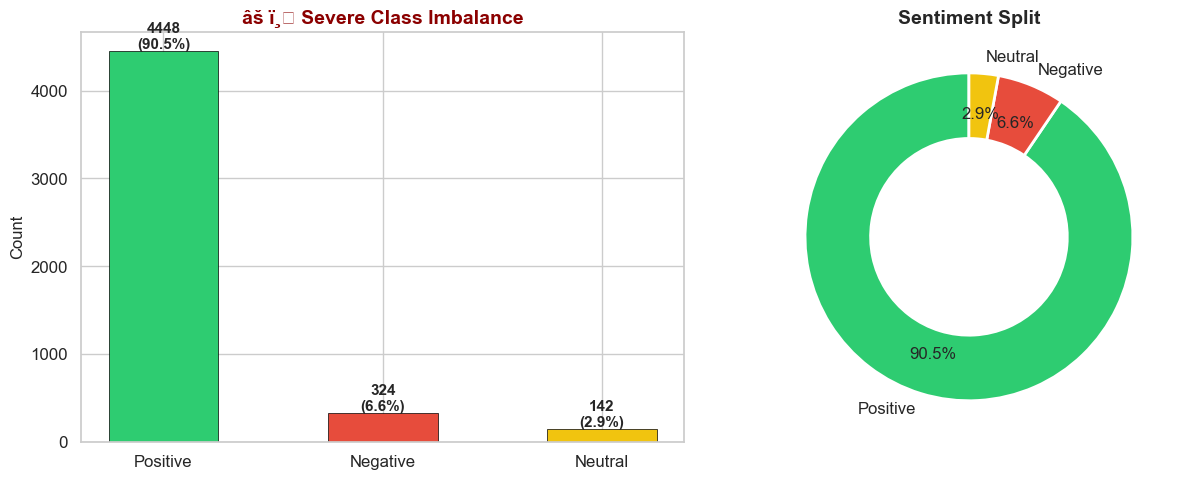

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sent_counts = df['sentiment_label'].value_counts()
bar_colors = ['#2ecc71', '#e74c3c', '#f1c40f'] # Positive, Negative, Neutral respectively based on value_counts order

# Bar chart
bars = axes[0].bar(sent_counts.index, sent_counts.values, color=bar_colors,
                   edgecolor='black', linewidth=0.5, width=0.5)
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('âš ï¸ Severe Class Imbalance', fontsize=14, fontweight='bold', color='darkred')

# Donut chart
wedges, texts, autotexts = axes[1].pie(sent_counts.values, labels=sent_counts.index,
    autopct='%1.1f%%', colors=bar_colors, startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), textprops={'fontsize':12})
axes[1].set_title('Sentiment Split', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()


# ### ðŸ“ˆ EDA Chart 3: Review Length Analysis

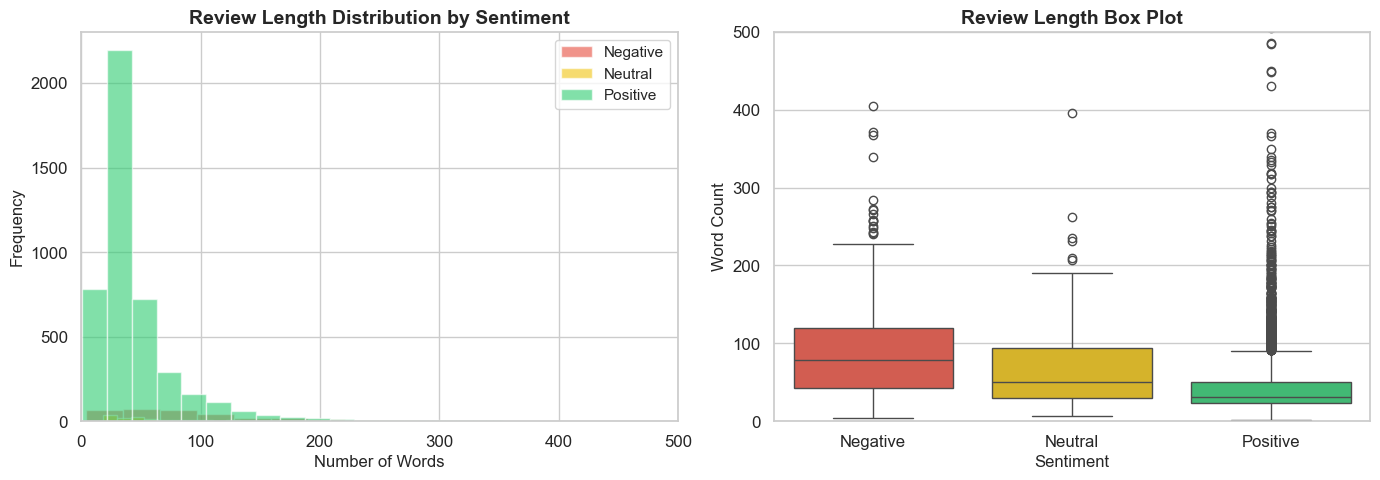

Average review length:
                       mean   50%     max
sentiment_label                          
Negative         106.478395  78.0  1554.0
Neutral           73.253521  50.0   580.0
Positive          45.643660  31.0  1037.0


In [7]:
df['review_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by sentiment
for label, color in zip(['Negative', 'Neutral', 'Positive'], ['#e74c3c', '#f1c40f', '#2ecc71']):
    subset = df[df['sentiment_label'] == label]['review_length']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_xlabel('Number of Words', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Review Length Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, 500)

# Box plot
sns.boxplot(data=df, x='sentiment_label', y='review_length', palette=['#e74c3c', '#f1c40f', '#2ecc71'], order=['Negative', 'Neutral', 'Positive'], ax=axes[1])
axes[1].set_ylim(0, 500)
axes[1].set_title('Review Length Box Plot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Word Count', fontsize=12)

plt.tight_layout()
plt.savefig('../models/eda_review_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average review length:')
print(df.groupby('sentiment_label')['review_length'].describe()[['mean', '50%', 'max']])


# ---
# ## ðŸ§¹ 2. Text Preprocessing

In [8]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
# Keep negation words â€” crucial for sentiment!
negation_words = {'not', 'no', 'nor', 'neither', 'never', 'none', 'nobody',
                  'nothing', 'nowhere', 'hardly', 'barely', 'scarcely',
                  "don't", "doesn't", "didn't", "won't", "wouldn't",
                  "can't", "couldn't", "shouldn't", "isn't", "aren't",
                  "wasn't", "weren't", "hasn't", "haven't", "hadn't"}
stop_words = stop_words - negation_words

# Pre-compile regex patterns for performance
html_pattern = re.compile(r'<[^>]+>')
url_pattern = re.compile(r'http\S+|www\S+')
non_alpha_pattern = re.compile(r'[^a-z\s]')
stop_words_pattern = re.compile(r'\b(' + r'|'.join(stop_words) + r')\b\s*')

def clean_text(text):
    text = str(text).lower()
    text = html_pattern.sub('', text)            # Remove HTML tags
    text = url_pattern.sub('', text)             # Remove URLs
    text = non_alpha_pattern.sub('', text)       # Keep only letters
    text = stop_words_pattern.sub('', text)      # Remove stopwords
    # Remove single characters (except a, i) and extra spaces
    text = re.sub(r'\b(?!a\b|i\b)[a-z]\b', '', text)
    return ' '.join(text.split())

df['clean_text'] = df['reviewText'].apply(clean_text)
print('Sample cleaned reviews:')
for i in range(3):
    print(f'  [{df.iloc[i]["sentiment_label"]}] {df.iloc[i]["clean_text"][:100]}...')



# ---
# ## âœ‚ï¸ 3. Train-Test Split & Tokenization

Sample cleaned reviews:
  [Positive] no issues...
  [Positive] purchased device worked advertised never much phone memory since download lot stuff no brainer...
  [Positive] works expected sprung higher capacity think made bit cheesier earlier versions paint looks not clean...


In [9]:
X = df['clean_text'].values
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train class distribution: {Counter(y_train)}')
print(f'Test  class distribution: {Counter(y_test)}')

Train: 3931 | Test: 983
Train class distribution: Counter({np.int64(2): 3558, np.int64(0): 259, np.int64(1): 114})
Test  class distribution: Counter({np.int64(2): 890, np.int64(0): 65, np.int64(1): 28})


In [10]:
VOCAB_SIZE = 15000
MAX_LEN = 200
EMBEDDING_DIM = 128

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train),
                            maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test),
                           maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size: {min(len(tokenizer.word_index)+1, VOCAB_SIZE)}')
print(f'Train shape: {X_train_seq.shape}')
print(f'Test  shape: {X_test_seq.shape}')

# Save tokenizer
with open('../trained_models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('\nâœ… Tokenizer saved to trained_models/tokenizer.pkl')


# ---
# ## âš–ï¸ 4. Handling Class Imbalance
# 
# We use **two strategies** to combat the severe imbalance:
# 1. **Random oversampling** of the minority class (negative reviews) to balance the training data
# 2. **Class weights** as a secondary safeguard during training

Vocabulary size: 8559
Train shape: (3931, 200)
Test  shape: (983, 200)

âœ… Tokenizer saved to trained_models/tokenizer.pkl


---

In [11]:
neg_indices = np.where(y_train == 0)[0]
neu_indices = np.where(y_train == 1)[0]
pos_indices = np.where(y_train == 2)[0]

n_pos = len(pos_indices)
n_neu = len(neu_indices)
n_neg = len(neg_indices)
print(f'Before oversampling â€” Positive: {n_pos}, Neutral: {n_neu}, Negative: {n_neg}')

# Oversample negative and neutral reviews to match positive count
oversampled_neg_indices = np.random.choice(neg_indices, size=n_pos, replace=True)
oversampled_neu_indices = np.random.choice(neu_indices, size=n_pos, replace=True)

balanced_indices = np.concatenate([pos_indices, oversampled_neu_indices, oversampled_neg_indices])
np.random.shuffle(balanced_indices)

X_train_balanced = X_train_seq[balanced_indices]
y_train_balanced = y_train[balanced_indices]

print(f'After  oversampling â€” Positive: {sum(y_train_balanced==2)}, Neutral: {sum(y_train_balanced==1)}, Negative: {sum(y_train_balanced==0)}')
print(f'Total training samples: {len(y_train_balanced)}')

# --- Strategy 2: Class weights (lighter, as backup) ---
classes = np.unique(y_train_balanced)
weights = compute_class_weight('balanced', classes=classes, y=y_train_balanced)
class_weights = dict(zip(classes, weights))
print(f'\nClass weights: {class_weights}')


# ### ðŸ“ˆ EDA Chart 4: Before vs After Balancing

Before oversampling â€” Positive: 3558, Neutral: 114, Negative: 259
After  oversampling â€” Positive: 3558, Neutral: 3558, Negative: 3558
Total training samples: 10674

Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}


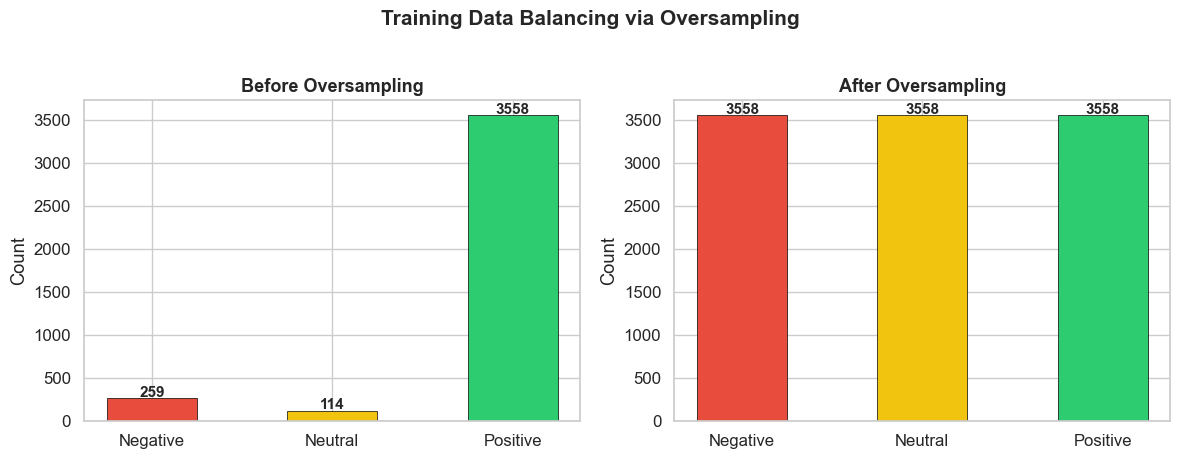

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

before = [n_neg, n_neu, n_pos]
after = [sum(y_train_balanced==0), sum(y_train_balanced==1), sum(y_train_balanced==2)]
labels = ['Negative', 'Neutral', 'Positive']
bar_colors = ['#e74c3c', '#f1c40f', '#2ecc71']

for ax, vals, title in zip(axes, [before, after], ['Before Oversampling', 'After Oversampling']):
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='black', linewidth=0.5, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(v), ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Training Data Balancing via Oversampling', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/eda_oversampling.png', dpi=150, bbox_inches='tight')
plt.show()


# ---
# ## ðŸ§  5. Model Architecture
# 
# **Improved architecture:**
# - Larger embedding dimension (128)
# - `SpatialDropout1D` after embedding (regularizes word vectors)
# - Stacked Bidirectional LSTM layers
# - Batch normalization for training stability
# - Learning rate scheduler for fine-tuning

In [13]:
model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),

    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    Bidirectional(LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)),

    BatchNormalization(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.summary()


# ---
# ## ðŸ‹ï¸ 6. Model Training

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 15
BATCH_SIZE = 64

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_balanced, y_train_balanced,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_seq, y_test),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


# ---
# ## ðŸ“Š 7. Training History Charts                                                                                                                                                                                                                                                  

Epoch 1/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 713s 4s/step - accuracy: 0.7639 - loss: 0.5373 - val_accuracy: 0.8291 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 2/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 675s 4s/step - accuracy: 0.9754 - loss: 0.0909 - val_accuracy: 0.9084 - val_loss: 0.3232 - learning_rate: 0.0010
Epoch 3/15
 90/167 ━━━━━━━━━━━━━━━━━━━━ 5:18 4s/step - accuracy: 0.9851 - loss: 0.0450

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], 'o-', label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], 's-', label='Val Loss', color='#e74c3c', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], 'o-', label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_accuracy'], 's-', label='Val Accuracy', color='#e67e22', linewidth=2)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/training_history.png', dpi=150, bbox_inches='tight')
plt.show()


# ---
# ## ðŸ“‹ 8. Model Evaluation

Predict

In [ ]:
y_pred_prob = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_prob, axis=1)

print('=' * 55)
print('           CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


# ### ðŸ“ˆ Evaluation Chart 1: Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'],
            annot_kws={'size': 16})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'],
            annot_kws={'size': 16})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


# ### ðŸ“ˆ Evaluation Chart 2: ROC Curve

One-vs-Rest ROC curve for multiclass

In [ ]:
plt.figure(figsize=(7, 6))
colors = ['#e74c3c', '#f1c40f', '#2ecc71']
labels = ['Negative', 'Neutral', 'Positive']
for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{labels[i]} ROC (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves For 3 Classes', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# ### ðŸ“ˆ Evaluation Chart 3: Precision-Recall Curve

Calculate Precision-Recall curve for each class

In [ ]:
precision_vals = dict()
recall_vals = dict()
for i in range(3):
    precision_vals[i], recall_vals[i], _ = precision_recall_curve(y_test == i, y_pred_prob[:, i])

plt.figure(figsize=(7, 6))
colors = ['#e74c3c', '#f1c40f', '#2ecc71']
labels = ['Negative', 'Neutral', 'Positive']
for i, color in zip(range(3), colors):
    plt.plot(recall_vals[i], precision_vals[i], color=color, linewidth=2.5, label=f'{labels[i]} PR Curve')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves For 3 Classes', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# ### ðŸ“ˆ Evaluation Chart 4: Per-Class Performance Comparison

In [ ]:
report = classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
neg_scores = [report['Negative'][m] for m in metrics]
neu_scores = [report['Neutral'][m] for m in metrics]
pos_scores = [report['Positive'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, neg_scores, width, label='Negative', color='#e74c3c', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, neu_scores, width, label='Neutral', color='#f1c40f', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, pos_scores, width, label='Positive', color='#2ecc71', edgecolor='black', linewidth=0.5)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Model Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../models/per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()


# ---
# ## ðŸ’¾ 9. Save Best Model

Save as .h5 (native Keras format)

In [ ]:
model.save('../trained_models/best_sentiment_model.h5')
print('model saved as best_sentiment_model.h5')

# Save as .pkl (model config + weights â€” as requested)
model_data = {
    'config': model.get_config(),
    'weights': model.get_weights(),
    'vocab_size': VOCAB_SIZE,
    'max_length': MAX_LEN,
    'embedding_dim': EMBEDDING_DIM
}
with open('../trained_models/best_sentiment_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)
print(' Model saved as best_sentiment_model.pkl')

print(' Files in trained_models:')
for fname in os.listdir('../trained_models'):
    fsize = os.path.getsize(f'../trained_models/{fname}') / (1024*1024)
    print(f'  {fname} ({fsize:.2f} MB)')


# ---
# ## ðŸ”® 10. Test Predictions on Sample Reviews

In [ ]:
sample_reviews = [
    'This product is amazing! Best purchase I have ever made. Highly recommended!',
    'Terrible quality. Broke after one week. Complete waste of money.',
    'Works as expected, nothing special but does the job.',
    'Absolutely horrible experience. The item arrived damaged and customer service was unhelpful.',
    'Love it! Great value for money and super fast shipping.',
    'It is okay I guess. Not the best, but not the worst either.'
]

cleaned = [clean_text(r) for r in sample_reviews]
seq = pad_sequences(tokenizer.texts_to_sequences(cleaned), maxlen=MAX_LEN, padding='post', truncating='post')
preds = model.predict(seq)

print('\n' + '='*65)
print('  SAMPLE PREDICTIONS (3-Class Classification)')
print('='*65)
sentiment_map = {0: ' NEGATIVE', 1: ' NEUTRAL', 2: ' POSITIVE'}
for review, prob_array in zip(sample_reviews, preds):
    predicted_class = np.argmax(prob_array)
    confidence = prob_array[predicted_class] * 100
    sentiment = sentiment_map[predicted_class]
    print(f'\n  Review: "{review[:70]}..."')
    print(f'  Prediction: {sentiment} (confidence: {confidence:.1f}%)')